# Rearrangement Testing - PSF occupancy

Same experiment as `rearrangement-testing.ipynb`, software pipeline only, with occupancy
called by a matched filter instead of a box sum.

One `analysis.SiteScorer` is built from the baseline images and then used everywhere:
the loading statistics, the survival check, and the rearrangement hot path.

In [1]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.slm import SLM
from pytweezer.drivers.thorcam import ThorCamera
from pytweezer.experiment.experiment_parameter_manager import ExpParameterManager
import pytweezer.phasemask as pm
import pytweezer.analysis as an
import numpy as np
import matplotlib.pyplot as plt

ExpParams = ExpParameterManager()

In [2]:
exp : MotMasterClient = MotMasterClient()
motcam : ThorCamera = ThorCamera(id="motcam")
slm : SLM = SLM()
hamcam : ImagEMX2Camera = ImagEMX2Camera()

Rb MotMasterClient initialised.
Thorlabs TLCamera - motcam - initialised.
SLM 1 initialised: 1024x1024 @ 8-bit, serial 7752, 40.169 degC
SLM 1 loaded LUT "C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT"
ImagEM X2 camera initialised.


In [3]:
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")

motcam.set_trigger_source("bulb")

hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(600)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

## MOT Check

MOT detected at (x, y): (935, 563)


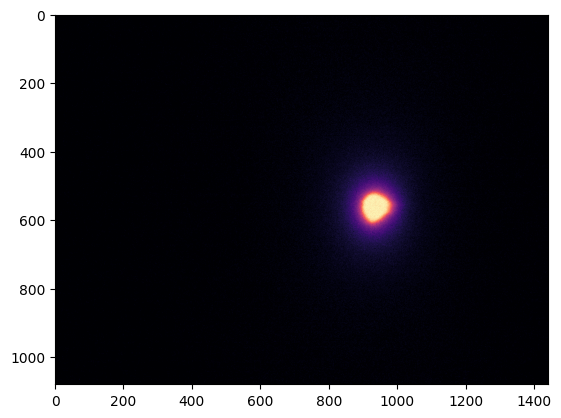

In [4]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
motcam.setup_acquisition(nframes=bg_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"),
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1,
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000})
imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

exp.set_iterations(img_it)
motcam.setup_acquisition(nframes=img_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"),
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1,
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000})
imgs = motcam.acquire_n_frames(nframes=img_it)
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma', vmin=0)

try:
    gaussian_params = an.fit_gaussian(img_mean)
    centre_x, centre_y = int(gaussian_params["x0"]), int(gaussian_params["y0"])
    print(f"MOT detected at (x, y): ({centre_x}, {centre_y})")
except Exception as e:
    print(f"Could not detect MOT: {e}")

## Generate Tweezer Array

In [4]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


In [5]:
W1 = np.ones((10,10))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.60e-05 | Uniformity: 51.73% | Min/Max ratio: 0.050
Iteration 010 | Mean-Squared Error: 1.54e-07 | Uniformity: 83.78% | Min/Max ratio: 0.520
Iteration 020 | Mean-Squared Error: 3.84e-08 | Uniformity: 83.44% | Min/Max ratio: 0.524
Iteration 030 | Mean-Squared Error: 7.11e-09 | Uniformity: 83.45% | Min/Max ratio: 0.532
Iteration 040 | Mean-Squared Error: 6.02e-09 | Uniformity: 83.45% | Min/Max ratio: 0.527
Iteration 050 | Mean-Squared Error: 6.68e-09 | Uniformity: 83.52% | Min/Max ratio: 0.522
Iteration 060 | Mean-Squared Error: 3.81e-09 | Uniformity: 83.56% | Min/Max ratio: 0.526
Iteration 070 | Mean-Squared Error: 6.57e-10 | Uniformity: 83.54% | Min/Max ratio: 0.527
Iteration 080 | Mean-Squared Error: 3.53e-10 | Uniformity: 83.54% | Min/Max ratio: 0.528
Iteration 090 | Mean-Squared Error: 4.69e-10 | Uniformity: 83.56% | Min/Max ratio: 0.529
Itera

In [6]:
W2 = np.ones((6,6))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W2, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W2 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms2 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array2, terms2, _ = PM.superposition_optimization(terms2, max_iter=5000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 6x6
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.19e-04 | Uniformity: 57.41% | Min/Max ratio: 0.125
Iteration 010 | Mean-Squared Error: 8.42e-07 | Uniformity: 89.55% | Min/Max ratio: 0.632
Iteration 020 | Mean-Squared Error: 3.82e-08 | Uniformity: 89.87% | Min/Max ratio: 0.673
Iteration 030 | Mean-Squared Error: 2.52e-08 | Uniformity: 89.91% | Min/Max ratio: 0.678
Iteration 040 | Mean-Squared Error: 5.03e-08 | Uniformity: 89.99% | Min/Max ratio: 0.680
Iteration 050 | Mean-Squared Error: 3.77e-08 | Uniformity: 89.92% | Min/Max ratio: 0.682
Iteration 060 | Mean-Squared Error: 1.36e-07 | Uniformity: 89.89% | Min/Max ratio: 0.686
Iteration 070 | Mean-Squared Error: 6.22e-08 | Uniformity: 90.46% | Min/Max ratio: 0.695
Iteration 080 | Mean-Squared Error: 7.87e-09 | Uniformity: 90.20% | Min/Max ratio: 0.690
Iteration 090 | Mean-Squared Error: 3.04e-10 | Uniformity: 90.12% | Min/Max ratio: 0.688
Iterati

In [7]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

## Baseline - Initial Array

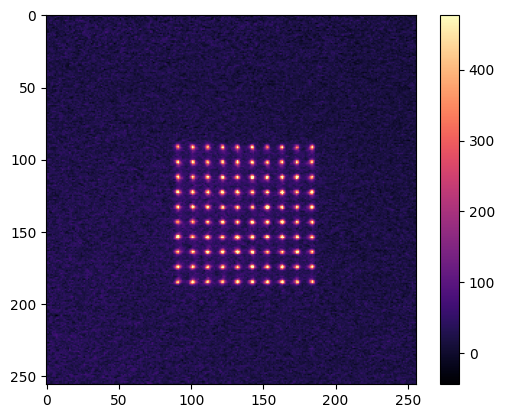

In [8]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 1})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = an.tweezer_show_bg_subtracted(imgs1, imgs2, cmap='magma', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
10x10 array detected.


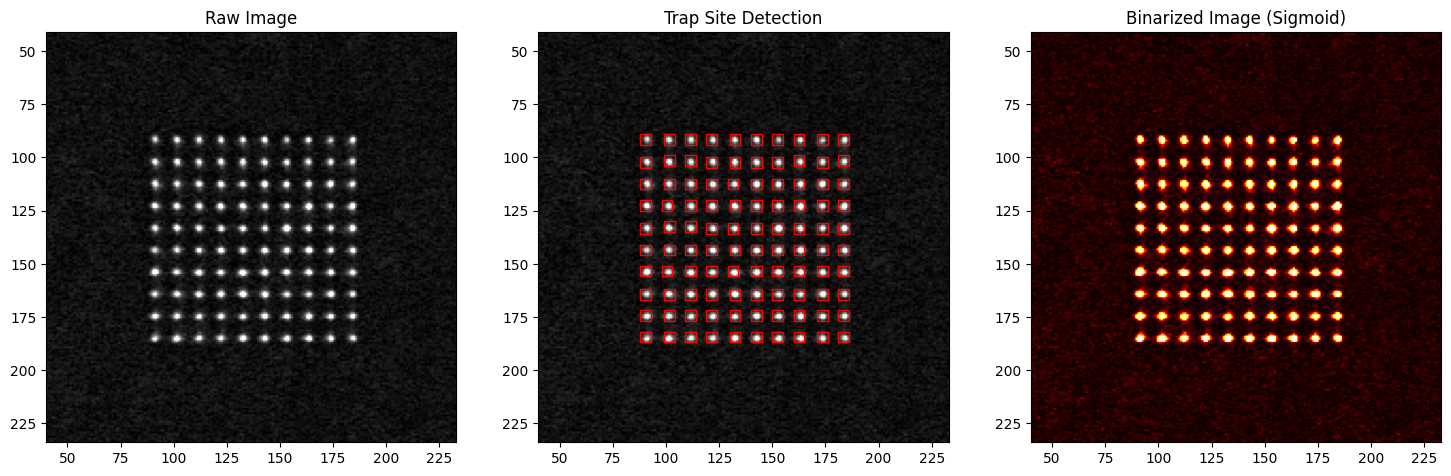

Trap (0, 0) Loading Probability : 56.00 %
Trap (0, 1) Loading Probability : 58.00 %
Trap (0, 2) Loading Probability : 50.00 %
Trap (0, 3) Loading Probability : 58.00 %
Trap (0, 4) Loading Probability : 55.00 %
Trap (0, 5) Loading Probability : 56.00 %
Trap (0, 6) Loading Probability : 48.00 %
Trap (0, 7) Loading Probability : 55.00 %
Trap (0, 8) Loading Probability : 52.00 %
Trap (0, 9) Loading Probability : 59.00 %
Trap (1, 0) Loading Probability : 60.00 %
Trap (1, 1) Loading Probability : 55.00 %
Trap (1, 2) Loading Probability : 55.00 %
Trap (1, 3) Loading Probability : 52.00 %
Trap (1, 4) Loading Probability : 59.00 %
Trap (1, 5) Loading Probability : 63.00 %
Trap (1, 6) Loading Probability : 51.00 %
Trap (1, 7) Loading Probability : 58.00 %
Trap (1, 8) Loading Probability : 55.00 %
Trap (1, 9) Loading Probability : 55.00 %
Trap (2, 0) Loading Probability : 60.00 %
Trap (2, 1) Loading Probability : 53.00 %
Trap (2, 2) Loading Probability : 58.00 %
Trap (2, 3) Loading Probability : 

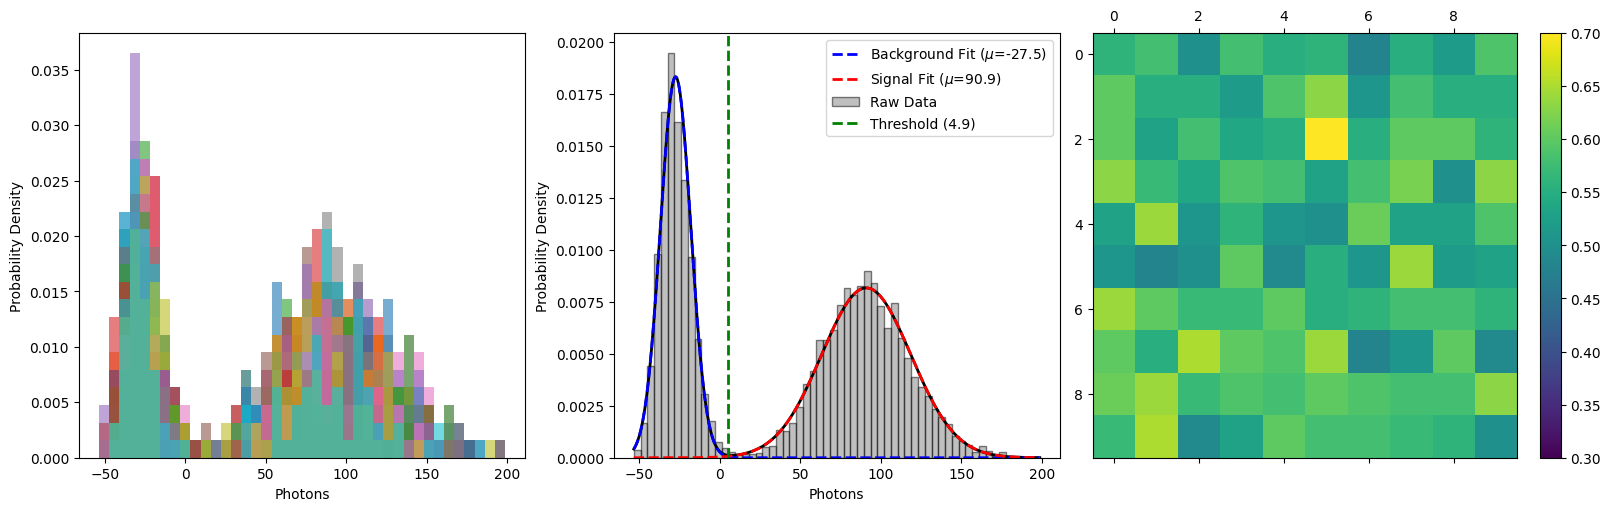

In [9]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10
psf_window = 9

filtered_img_average = an.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(filtered_img_average, array_shape_1, detection_step=200)
an.visualize_results(filtered_img_average, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

# Templates come from the raw frames - the matched filter needs no top-hat.
scorer = an.SiteScorer.from_images(imgs1, grid_positions_1, array_shape_1, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(
    imgs1, grid_positions_1, array_shape_1, scorer=scorer, threshold_detection=True, binning=60)

scorer.threshold = threshold_1 * 1.1
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

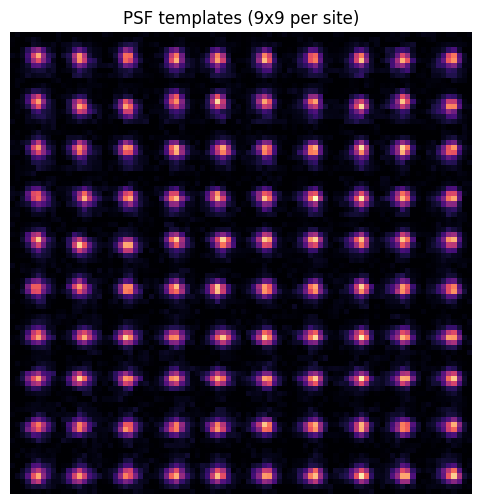

In [10]:
montage = np.block([[scorer.templates[(r, c)] for c in range(array_shape_1[1])]
                    for r in range(array_shape_1[0])])
plt.figure(figsize=(6, 6))
plt.imshow(montage, cmap='magma')
plt.title(f"PSF templates ({psf_window}x{psf_window} per site)")
plt.axis('off')
plt.show()

## Baseline Survival

In [ ]:
# Experiment and camera setup
n_iterations = 200
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 0})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]

In [ ]:
before = np.array([scorer.occupancy(img) for img in imgs1])
after = np.array([scorer.occupancy(img) for img in imgs2])
baseline_survival_probability = (before & after).sum() / before.sum()

print(f"Initial filling: {before.mean()*100:.1f} %")
print(f"Baseline survival probability: {baseline_survival_probability:.4f}")

## Rearrangement Init

In [11]:
# The scorer is already in photons; threshold_count is only for the coordinator's
# fallback path, which still works in counts.
threshold_count = an.convert_photons_to_counts(threshold_1) * 1.1
print(f"PSF threshold {scorer.threshold:.2f} photons ({threshold_count:.1f} counts)")

PSF threshold 5.37 photons (2572.5 counts)


In [12]:
import asyncio
from pytweezer.coordinators.rearrangement import Rearrangement

coordinator = Rearrangement({"camera": hamcam, "slm": slm, "phasemask_generator": PM}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]
await asyncio.to_thread(
    coordinator.initialise,
    data1, data2, array_shape1, array_shape2,
    d0=0.5, fps=1/(1e-6), threshold=threshold_count,
    grid_positions=grid_positions_1, profile="linear",
    detector=scorer
)



Occupancy via PSF detector (window 9, threshold 5.4).
Rearrangement node initialised.


## Rearrangement Exp

In [13]:
import time

# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [14]:
N_iterations = 100  # adjust before running
imgs_software, err_indices, timings_log, pairings_log = [], [], [], []

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement_timings))

    time.sleep(0.1)
    exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 0})
    img0, img1, timings, pairing = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if img1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs_software.append([img0, img1])
    timings_log.append(timings)
    # Logged for every run, discarded ones included: the assignment is still a
    # valid record of what the pairing decided, even if the reset frame was lost.
    pairings_log.append(pairing)

print(f"\nDone: {len(timings_log)} runs logged, {len(err_indices)} discarded.")


Running experiment iteration 1 / 100
Reset-image acquisition failed; returning zeros.
Rearrangement complete: 15 frames, 40.2887ms total (occupancy 0.2018ms, pairing+setup 27.5349ms, streaming 12.5520ms).
  per-frame medians (frame 0 excluded): compute 0.2546ms, gpu-wait 0.0008ms, transfer 0.0513ms, board-write 0.5885ms, pacing 0.0499ms.
  time to first frame 30.2276ms, pinned alloc 0.0691ms.
Images acquired from rearrangement node.
Empty image received at iteration 1. Discarding...
Running experiment iteration 2 / 100
Rearrangement complete: 23 frames, 19.6982ms total (occupancy 0.1201ms, pairing+setup 2.1312ms, streaming 17.4469ms).
  per-frame medians (frame 0 excluded): compute 0.2576ms, gpu-wait 0.0008ms, transfer 0.0571ms, board-write 0.5733ms, pacing 0.0539ms.
  time to first frame 4.1178ms, pinned alloc 0.0444ms.
Images acquired from rearrangement node.
Running experiment iteration 3 / 100
Rearrangement complete: 15 frames, 14.2533ms total (occupancy 0.1950ms, pairing+setup 2.2

In [15]:
def per_run(key):
    return np.array([t[key] for t in timings_log], dtype=float)

def pooled(key, skip_first=True):
    """All frames from all runs, frame 0 of each run dropped by default."""
    out = []
    for t in timings_log:
        v = t[key]
        out.extend(v[1:] if skip_first and len(v) > 1 else v)
    return np.array(out, dtype=float)

def frame0(key):
    return np.array([t[key][0] for t in timings_log if t[key]], dtype=float)

n_frames = per_run("n_frames")

# --- one-time costs, per run ---
print("=== one-time cost per rearrangement (median over runs) ===")
for label, key in (("occupancy extraction", "occupancy_extraction_ms"),
                   ("JV pairing + setup   ", "pairing_and_setup_ms"),
                   ("pinned alloc         ", "pinned_alloc_ms"),
                   ("time to first frame  ", "time_to_first_frame_ms")):
    v = per_run(key)
    print(f"  {label} = {np.nanmedian(v):7.4f} ms   (IQR {np.nanpercentile(v,25):.4f}-{np.nanpercentile(v,75):.4f})")

# --- per-frame stages, steady state (frame 0 excluded) ---
compute  = pooled("gpu_compute_ms")
wait     = pooled("gpu_wait_ms")
transfer = pooled("transfer_ms")
display  = pooled("display_ms")
pacing   = pooled("pacing_ms")

print(f"\n=== per-frame stages, steady state, {compute.size} frames pooled ===")
for label, v in (("GPU compute (overlapped)", compute),
                 ("GPU wait  (writer stall)", wait),
                 ("PCIe transfer D->H      ", transfer),
                 ("board write (update_mask)", display),
                 ("panel pacing (deliberate)", pacing)):
    print(f"  {label} = {np.median(v):7.4f} ms   (IQR {np.percentile(v,25):.4f}-{np.percentile(v,75):.4f})")

cycle          = wait + transfer + display + pacing
cycle_unpaced  = wait + transfer + display
serial_equiv   = compute + transfer + display   # if compute could not overlap

print(f"\n  pipelined cycle                 = {np.median(cycle):7.4f} ms/frame")
print(f"  pipelined cycle, pacing removed = {np.median(cycle_unpaced):7.4f} ms/frame")
print(f"  same stages if serialised       = {np.median(serial_equiv):7.4f} ms/frame")
print(f"  -> overlap saves                  {np.median(serial_equiv) - np.median(cycle_unpaced):7.4f} ms/frame")

print(f"\n=== frame 0 vs steady state ===")
for label, key, steady in (("compute ", "gpu_compute_ms", compute),
                           ("wait    ", "gpu_wait_ms",    wait),
                           ("transfer", "transfer_ms",    transfer),
                           ("display ", "display_ms",     display)):
    f0 = np.median(frame0(key))
    print(f"  {label}: frame0 {f0:7.4f} ms  vs steady {np.median(steady):7.4f} ms  ({f0 - np.median(steady):+.4f})")

occupancy = per_run("occupancy_extraction_ms")
setup     = per_run("pairing_and_setup_ms")
streaming = per_run("streaming_ms")
total     = per_run("total_rearrangement_ms")

print(f"\n=== fixed vs per-frame ===")
if len(np.unique(n_frames)) < 2:
    print(f"  all shots used {n_frames[0]:.0f} frames - cannot separate fixed from per-frame cost.")
else:
    for label, y in (("streaming (frames only)", streaming), ("total", total)):
        per_frame, fixed = np.polyfit(n_frames, y, 1)
        resid = y - (per_frame * n_frames + fixed)
        print(f"  {label:24s}: {fixed:6.3f} ms fixed + {per_frame:.3f} ms/frame  (residual sd {resid.std():.3f} ms)")
    print(f"  n_frames spanned {n_frames.min():.0f}-{n_frames.max():.0f} over {n_frames.size} runs")


last_pace = np.array([t["pacing_ms"][-1] for t in timings_log], dtype=float)
calc_to_slm = streaming - last_pace
med = lambda v: float(np.median(v))

nf = med(n_frames)
print("\n" + "=" * 60)
print(f"  ONE REARRANGEMENT  -  median of {len(timings_log)} runs, {nf:.0f} frames typical")
print("=" * 60)
print(f"   camera image -> occupancy mask        {med(occupancy):7.3f} ms")
print(f"   pairing + interpolation setup         {med(setup):7.3f} ms")
print(f"   FIRST CALC -> LAST FRAME ON SLM       {med(calc_to_slm):7.3f} ms   <<<")
print(f"   (trailing pace after last write)      {med(last_pace):7.3f} ms")
print("   " + "-" * 45)
print(f"   total, camera -> sequence finished    {med(total):7.3f} ms")
print()
print(f"   calc -> SLM, per frame                {med(calc_to_slm)/nf:7.3f} ms/frame")
print(f"   all calculation (setup + streaming)   {med(setup + calc_to_slm):7.3f} ms")
print(f"   move duration only, atoms in flight   {med(calc_to_slm):7.3f} ms over {nf:.0f} frames")
print("=" * 60)


=== one-time cost per rearrangement (median over runs) ===
  occupancy extraction =  0.1587 ms   (IQR 0.1553-0.2022)
  JV pairing + setup    =  2.1651 ms   (IQR 2.1217-2.2153)
  pinned alloc          =  0.0460 ms   (IQR 0.0436-0.0518)
  time to first frame   =  4.1732 ms   (IQR 3.9816-4.3470)

=== per-frame stages, steady state, 1838 frames pooled ===
  GPU compute (overlapped) =  0.2442 ms   (IQR 0.2182-0.2921)
  GPU wait  (writer stall) =  0.0008 ms   (IQR 0.0006-0.0029)
  PCIe transfer D->H       =  0.0570 ms   (IQR 0.0454-0.0796)
  board write (update_mask) =  0.5826 ms   (IQR 0.5659-0.5981)
  panel pacing (deliberate) =  0.0461 ms   (IQR 0.0277-0.0649)

  pipelined cycle                 =  0.6956 ms/frame
  pipelined cycle, pacing removed =  0.6489 ms/frame
  same stages if serialised       =  0.8950 ms/frame
  -> overlap saves                   0.2460 ms/frame

=== frame 0 vs steady state ===
  compute : frame0  0.4132 ms  vs steady  0.2442 ms  (+0.1690)
  wait    : frame0  0.003

### Saved assignment data

Each run folder now carries `pairing.npz` next to the images and timings, and the
whole scan is flattened into `assignments.csv` / `pairing_summary.csv` at the top
level. `array_metadata.npz` holds the conventions needed to read them.

Index conventions - the occupancy mask the coordinator uses is
`np.fliplr(scorer.score_grid(img)).flatten()`, so a flat trap index `f` of the
initial array is grid site `(f // n_cols, n_cols - 1 - f % n_cols)` in
`grid_positions_1`. `site_keys` and `site_pixels` in `array_metadata.npz` do that
lookup for every `f`, so `site_pixels[moving_idx[n]]` is the `(y, x)` camera pixel
the n-th moved atom started at.

Per run, `pairing.npz` contains:

| key | meaning |
| --- | --- |
| `occ_mask` | bool, one per initial site - what the PSF scorer called occupied |
| `occupied_idx` | flat indices of the loaded sites |
| `moving_idx` | flat initial index of each moved atom, in JV pair order |
| `final_idx` | flat target index it was sent to, same order |
| `pos_init`, `pos_final` | start and end coordinates of each moved atom |
| `moving_site_key`, `moving_site_pixel` | `moving_idx` mapped to grid site / camera pixel |
| `discarded_idx` | loaded sites the assignment did not use (trap switched off) |
| `unfilled_target_idx` | target sites no atom was available for |

Per-atom survival is then: atom `n` of run `i` survived if the final image scores
above threshold at target site `final_idx[n]`. That needs the target array's own
grid positions in camera pixels - build a second `SiteScorer` on the mean final
image with `array_shape2` and keep the same `fliplr` convention so its flat index
matches `final_idx`.

In [ ]:
from pathlib import Path
import json
import numpy as np
import tifffile

BASE = Path(r"C:\Peter_Dunniece_Project_MSc\pytweezer\Local_Files\rearrangement_data")
BASE.mkdir(parents=True, exist_ok=True)

# imgs_software only holds the runs that were kept, timings_log holds every run,
# so rebuild the run index -> image pair mapping through err_indices.
kept = [i for i in range(len(timings_log)) if i not in set(err_indices)]
images_by_run = dict(zip(kept, imgs_software))

SCALARS = ["n_frames", "n_moving", "occupancy_extraction_ms", "pairing_and_setup_ms",
           "streaming_ms", "time_to_first_frame_ms", "pinned_alloc_ms",
           "calculation_and_upload_ms", "total_rearrangement_ms"]
MEDIANS = ["gpu_compute_median_ms", "gpu_wait_median_ms", "transfer_median_ms",
           "display_median_ms", "pacing_median_ms"]
SERIES  = ["gpu_compute_ms", "gpu_wait_ms", "transfer_ms", "display_ms", "pacing_ms"]

PAIR_ARRAYS  = ["occ_mask", "occupied_idx", "moving_idx", "final_idx",
                "pos_init", "pos_final", "discarded_idx", "unfilled_target_idx"]
PAIR_SCALARS = ["n_occupied", "n_moving", "n_targets"]


# ------------------------------------------------------------------ #
# Index conventions, resolved once
#
# The coordinator's occupancy mask is np.fliplr(score_grid).flatten(), so flat
# trap index f corresponds to grid site (f // n_cols, n_cols - 1 - f % n_cols)
# in grid_positions_1 / scorer.keys. site_pixels turns a flat index straight
# into the (row, col) camera pixel of that site, which is what a later
# per-atom survival check needs.
# ------------------------------------------------------------------ #
n_rows, n_cols = array_shape_1
site_keys = np.array([[f // n_cols, n_cols - 1 - f % n_cols]
                      for f in range(n_rows * n_cols)], dtype=np.int32)
site_pixels = np.array([grid_positions_1[(int(r), int(c))] for r, c in site_keys],
                       dtype=np.int32)

def _host(a):
    return np.asarray(a.get() if hasattr(a, "get") else a)

np.savez(BASE / "array_metadata.npz",
         array_shape_init=np.asarray(array_shape_1, dtype=np.int32),
         array_shape_target=np.asarray(array_shape2, dtype=np.int32),
         site_keys=site_keys, site_pixels=site_pixels,
         init_x=_host(terms1[2]), init_y=_host(terms1[3]),
         target_x=_host(terms2[2]), target_y=_host(terms2[3]),
         psf_threshold_photons=np.float64(scorer.threshold),
         psf_window=np.int32(psf_window))


def write_run(run_idx, timings, images, pairing):
    folder = BASE / f"rearrangement_run{run_idx + 1:03d}"
    folder.mkdir(exist_ok=True)

    if images is not None:
        for stem, img in (("image_initial", images[0]), ("image_final", images[1])):
            img = np.asarray(img)
            if img.dtype != np.uint16:
                # Don't silently truncate - say what came through instead.
                print(f"run {run_idx+1:03d}: {stem} is {img.dtype}, not uint16; saved as-is.")
            np.save(folder / f"{stem}.npy", img)
            tifffile.imwrite(folder / f"{stem}.tif", img)

    # Machine-readable, for reloading later without parsing text.
    json.dump({k: (list(map(float, v)) if isinstance(v, list) else float(v))
               for k, v in timings.items()},
              open(folder / "timings.json", "w"), indent=2)

    if pairing is not None:
        np.savez(folder / "pairing.npz",
                 **{k: np.asarray(pairing[k]) for k in PAIR_ARRAYS},
                 **{k: np.int32(pairing[k]) for k in PAIR_SCALARS},
                 moving_site_key=site_keys[pairing["moving_idx"]],
                 moving_site_pixel=site_pixels[pairing["moving_idx"]])

    lines = [f"rearrangement run {run_idx + 1:03d}",
             "=" * 46,
             "images saved" if images is not None else "images DISCARDED (empty final frame)",
             ""]
    for k in SCALARS:
        if k in timings:
            lines.append(f"  {k:<28s} {timings[k]:10.4f}")
    lines += ["", "  steady-state medians (frame 0 excluded)"]
    for k in MEDIANS:
        if k in timings:
            lines.append(f"    {k:<26s} {timings[k]:10.4f}")

    if pairing is not None:
        mv, fi = pairing["moving_idx"], pairing["final_idx"]
        dist = np.linalg.norm(pairing["pos_final"] - pairing["pos_init"], axis=1)
        lines += ["", "  JV assignment",
                  f"    {pairing['n_occupied']:d}/{len(pairing['occ_mask']):d} sites loaded, "
                  f"{pairing['n_moving']:d} moved, {len(pairing['discarded_idx']):d} discarded, "
                  f"{len(pairing['unfilled_target_idx']):d}/{pairing['n_targets']:d} targets unfilled",
                  f"    {'slot':>4s} {'init':>5s} {'site':>9s} {'px(y,x)':>11s} "
                  f"{'target':>7s} {'dist':>8s}"]
        for n in range(len(mv)):
            r, c = site_keys[mv[n]]
            py, px = site_pixels[mv[n]]
            lines.append(f"    {n:4d} {mv[n]:5d} {f'({r},{c})':>9s} {f'({py},{px})':>11s} "
                         f"{fi[n]:7d} {dist[n]:8.3f}")
        if len(pairing["discarded_idx"]):
            lines.append(f"    discarded (loaded, not moved): "
                         f"{', '.join(map(str, pairing['discarded_idx']))}")
        if len(pairing["unfilled_target_idx"]):
            lines.append(f"    unfilled targets: "
                         f"{', '.join(map(str, pairing['unfilled_target_idx']))}")

    lines += ["", "  per-frame series (ms)",
              f"    {'frame':>5s} {'compute':>9s} {'wait':>9s} {'transfer':>9s} {'display':>9s} {'pacing':>9s}"]
    for n in range(int(timings["n_frames"])):
        row = "  ".join(f"{timings[k][n]:8.4f}" for k in SERIES)
        lines.append(f"    {n:5d}   {row}")

    (folder / "timings.txt").write_text("\n".join(lines) + "\n", encoding="utf-8")
    return folder


for i, t in enumerate(timings_log):
    write_run(i, t, images_by_run.get(i), pairings_log[i] if i < len(pairings_log) else None)

print(f"Wrote {len(timings_log)} run folders to {BASE}")


# ------------------------------------------------------------------ #
# Every moved atom from every run, one row each. This is the table the
# per-atom survival analysis joins against: score image_final at
# target_flat's site and image_initial at init_flat's site.
# ------------------------------------------------------------------ #
with open(BASE / "assignments.csv", "w", encoding="utf-8") as f:
    f.write("run,images_kept,slot,init_flat,init_row,init_col,init_py,init_px,"
            "target_flat,x_init,y_init,x_final,y_final,dist\n")
    for i, p in enumerate(pairings_log):
        dist = np.linalg.norm(p["pos_final"] - p["pos_init"], axis=1)
        for n, (mi, fi) in enumerate(zip(p["moving_idx"], p["final_idx"])):
            r, c = site_keys[mi]
            py, px = site_pixels[mi]
            xi, yi = p["pos_init"][n]
            xf, yf = p["pos_final"][n]
            f.write(f"{i+1},{int(i in images_by_run)},{n},{mi},{r},{c},{py},{px},"
                    f"{fi},{xi:.4f},{yi:.4f},{xf:.4f},{yf:.4f},{dist[n]:.4f}\n")

# Loading and assignment yield per run, alongside the timing table.
with open(BASE / "pairing_summary.csv", "w", encoding="utf-8") as f:
    f.write("run,images_kept,n_sites,n_occupied,n_moving,n_discarded,n_targets,n_unfilled\n")
    for i, p in enumerate(pairings_log):
        f.write(f"{i+1},{int(i in images_by_run)},{len(p['occ_mask'])},{p['n_occupied']},"
                f"{p['n_moving']},{len(p['discarded_idx'])},{p['n_targets']},"
                f"{len(p['unfilled_target_idx'])}\n")


# ------------------------------------------------------------------ #
# Top-level summary across every run
# ------------------------------------------------------------------ #
def per_run(key):
    return np.array([t[key] for t in timings_log], dtype=float)

def pooled(key, skip_first=True):
    out = []
    for t in timings_log:
        v = t[key]
        out.extend(v[1:] if skip_first and len(v) > 1 else v)
    return np.array(out, dtype=float)

def frame0(key):
    return np.array([t[key][0] for t in timings_log if t[key]], dtype=float)

n_frames = per_run("n_frames")
compute, wait   = pooled("gpu_compute_ms"), pooled("gpu_wait_ms")
transfer        = pooled("transfer_ms")
display, pacing = pooled("display_ms"), pooled("pacing_ms")
cycle           = wait + transfer + display + pacing
streaming       = per_run("streaming_ms")
total           = per_run("total_rearrangement_ms")
last_pace       = np.array([t["pacing_ms"][-1] for t in timings_log], dtype=float)
calc_to_slm     = streaming - last_pace

S = [f"rearrangement summary - {len(timings_log)} runs "
     f"({len(imgs_software)} kept, {len(err_indices)} discarded)",
     "=" * 62, "",
     "one-time cost per rearrangement (median over runs)"]
for label, key in (("occupancy extraction", "occupancy_extraction_ms"),
                   ("JV pairing + setup", "pairing_and_setup_ms"),
                   ("pinned alloc", "pinned_alloc_ms"),
                   ("time to first frame", "time_to_first_frame_ms")):
    v = per_run(key)
    S.append(f"  {label:<24s} {np.nanmedian(v):8.4f} ms   "
             f"(IQR {np.nanpercentile(v,25):.4f}-{np.nanpercentile(v,75):.4f})")

S += ["", f"per-frame stages, steady state, {compute.size} frames pooled"]
for label, v in (("GPU compute (overlapped)", compute), ("GPU wait (writer stall)", wait),
                 ("PCIe transfer D->H", transfer), ("board write (update_mask)", display),
                 ("panel pacing (deliberate)", pacing)):
    S.append(f"  {label:<26s} {np.median(v):8.4f} ms   "
             f"(IQR {np.percentile(v,25):.4f}-{np.percentile(v,75):.4f})")

S += ["", f"  pipelined cycle              {np.median(cycle):8.4f} ms/frame  (marginal)",
      f"  calc -> SLM per frame        {np.median(calc_to_slm)/np.median(n_frames):8.4f} ms/frame  (average)",
      "", "frame 0 vs steady state"]
for label, key, steady in (("compute", "gpu_compute_ms", compute), ("wait", "gpu_wait_ms", wait),
                           ("transfer", "transfer_ms", transfer), ("display", "display_ms", display)):
    f0 = np.median(frame0(key))
    S.append(f"  {label:<10s} frame0 {f0:8.4f}  steady {np.median(steady):8.4f}  ({f0 - np.median(steady):+.4f})")

S += ["", "fixed vs per-frame"]
if len(np.unique(n_frames)) < 2:
    S.append(f"  all shots used {n_frames[0]:.0f} frames - cannot separate fixed from per-frame cost.")
else:
    for label, y in (("streaming (frames only)", streaming), ("total", total)):
        pf, fixed = np.polyfit(n_frames, y, 1)
        resid = y - (pf * n_frames + fixed)
        S.append(f"  {label:<24s} {fixed:7.3f} ms fixed + {pf:.3f} ms/frame "
                 f"(residual sd {resid.std():.3f} ms)")
    S.append(f"  n_frames spanned {n_frames.min():.0f}-{n_frames.max():.0f} over {n_frames.size} runs")

occupied = np.array([p["n_occupied"] for p in pairings_log], dtype=float)
moved    = np.array([p["n_moving"] for p in pairings_log], dtype=float)
unfilled = np.array([len(p["unfilled_target_idx"]) for p in pairings_log], dtype=float)
S += ["", "assignment (median over runs)",
      f"  sites loaded                      {np.median(occupied):8.1f} / {len(pairings_log[0]['occ_mask']):d}"
      f"  ({occupied.mean()/len(pairings_log[0]['occ_mask'])*100:.1f} % filling)",
      f"  atoms moved                       {np.median(moved):8.1f}",
      f"  targets left unfilled             {np.median(unfilled):8.1f} / {pairings_log[0]['n_targets']:d}",
      f"  runs with a complete target array {int((unfilled == 0).sum()):8d} / {len(pairings_log):d}"]

S += ["", "headline (median over runs)",
      f"  first calc -> last frame on SLM   {np.median(calc_to_slm):8.3f} ms "
      f"over {np.median(n_frames):.0f} frames",
      f"  camera -> sequence finished       {np.median(total):8.3f} ms",
      f"  mean n_frames                     {n_frames.mean():8.2f}"]

summary = "\n".join(S) + "\n"
(BASE / "summary.txt").write_text(summary, encoding="utf-8")

# One row per run, for plotting elsewhere.
cols = [c for c in SCALARS + MEDIANS if c in timings_log[0]]
with open(BASE / "all_runs.csv", "w", encoding="utf-8") as f:
    f.write("run,images_kept," + ",".join(cols) + "\n")
    for i, t in enumerate(timings_log):
        f.write(f"{i+1},{int(i in images_by_run)}," + ",".join(f"{t[c]:.6f}" for c in cols) + "\n")

print(summary)
print(f"Summary + all_runs.csv + assignments.csv written to {BASE}")


## Results

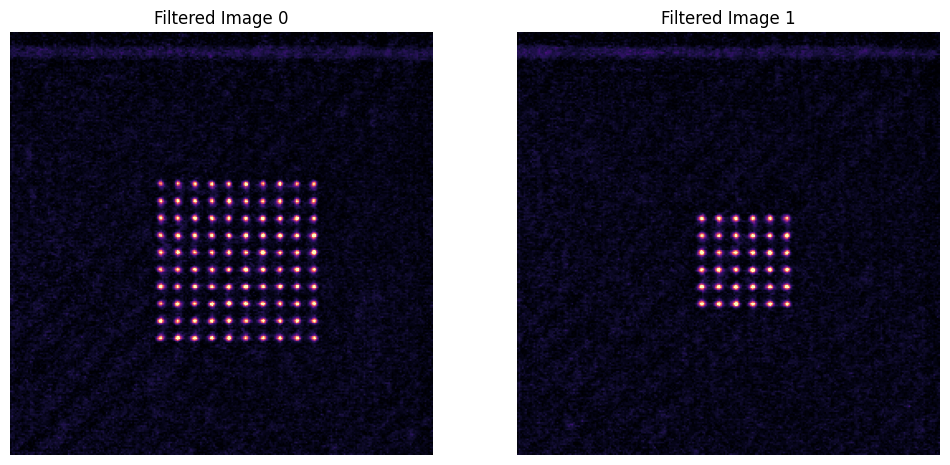

In [23]:
tot_imgs = np.array(imgs_software)

imgs0 = tot_imgs[:, 0, :, :]
imgs1 = tot_imgs[:, 1, :, :]

imgs0_mean = imgs0.mean(axis=0)
imgs1_mean = imgs1.mean(axis=0)

imgs0_mean_filtered = an.morphological_tophat_high_pass(imgs0_mean, feature_size=feature_size)
imgs1_mean_filtered = an.morphological_tophat_high_pass(imgs1_mean, feature_size=feature_size)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(imgs0_mean_filtered, cmap='magma', vmax=0.6*imgs0_mean_filtered.max())
plt.title('Filtered Image 0')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imgs1_mean_filtered, cmap='magma', vmax=0.6*imgs1_mean_filtered.max())
plt.title('Filtered Image 1')
plt.axis('off')

plt.show()

In [24]:
hamcam.close()
slm.close()
motcam.close()

ImagEM X2 camera closed.
SLM 1 closed.
Thorlabs TLCamera - motcam - closed.
